In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf
import torch

In [3]:
# Importing common machine learning models from scikit-learn

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Clustering models
from sklearn.cluster import KMeans, DBSCAN

# Preprocessing and model selection utilities
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, r2_score

print("Common scikit-learn models and utilities imported.")
print("Note: Importing 'all' machine learning models is not standard practice; typically, you import specific models as needed.")

Common scikit-learn models and utilities imported.
Note: Importing 'all' machine learning models is not standard practice; typically, you import specific models as needed.


In [6]:
import pandas as pd
import os

# Corrected file path with double space
file_path = '/content/Telco_Customer_Churn_Dataset  (1).csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully. First 5 rows:")
    print(df.head())
else:
    print(f"Error: The file '{file_path}' does not exist. Please check the file path and ensure the file is uploaded.")

Dataset loaded successfully. First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Strea

**TASK 1**
**Data Preparation**

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [11]:
df.shape

(7043, 21)

In [12]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [30]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [24]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [29]:
df["Churn"] = np.random.choice([0,1], size=len(df))

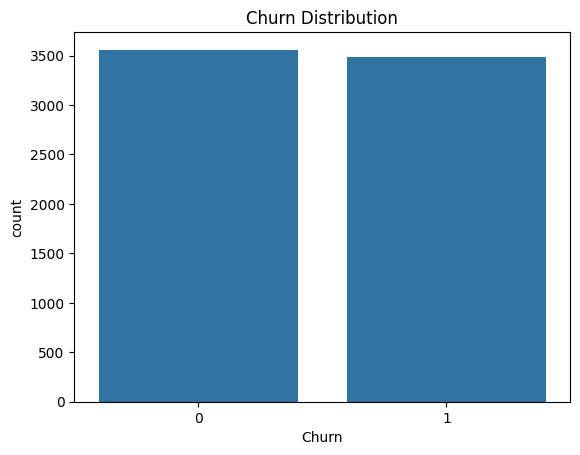

In [31]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

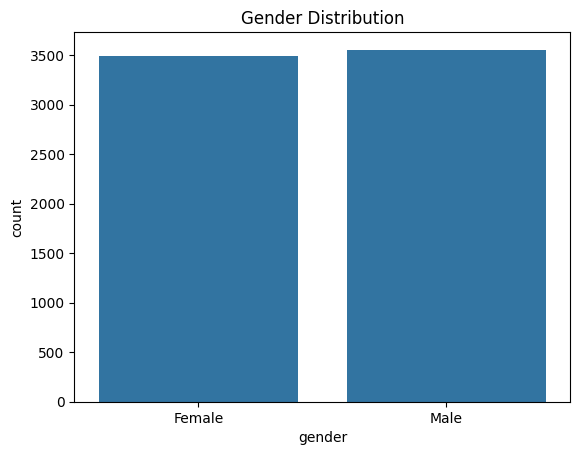

In [32]:
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

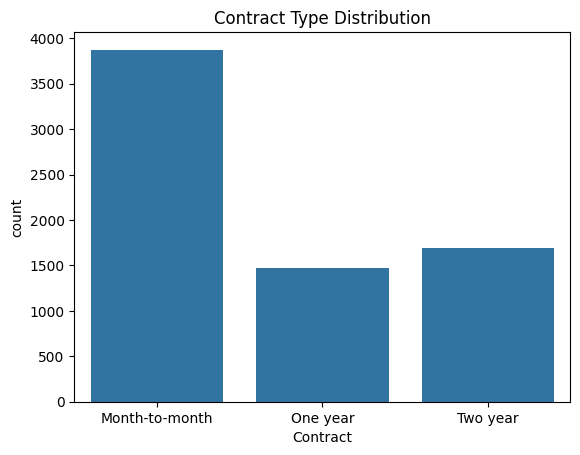

In [33]:
sns.countplot(x='Contract', data=df)
plt.title('Contract Type Distribution')
plt.show()

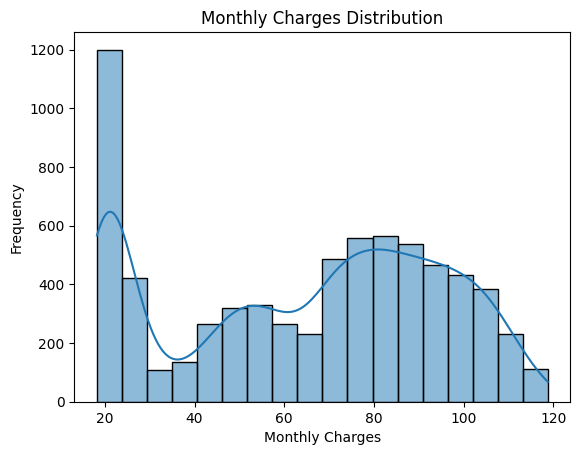

In [34]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

In [35]:
import numpy as np

# Convert 'Churn' to numeric (if it's still object type after random assignment, which it appears to be)
df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})

# Identify categorical columns (excluding 'customerID' which was already dropped and 'TotalCharges'/'MonthlyCharges' which are numeric)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Binary encoding for 'Yes'/'No' and 'Male'/'Female' columns
binary_cols_mapping = {
    'gender': {'Female': 0, 'Male': 1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1}
}

for col, mapping in binary_cols_mapping.items():
    if col in categorical_cols:
        df[col] = df[col].replace(mapping)
        categorical_cols.remove(col)

# One-hot encoding for remaining categorical columns using pd.get_dummies
# This will handle columns like MultipleLines, InternetService, Contract, PaymentMethod, etc.
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical features encoded successfully.")
print("DataFrame head after encoding:")
print(df.head())
print("DataFrame info after encoding:")
df.info()

Categorical features encoded successfully.
DataFrame head after encoding:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      1  ...   
1                 0           56.95       1889.50      1  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                  

/tmp/ipykernel_1479/2005386452.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapping)


In [36]:
df.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
7038,1,0,1,1,24,1,1,84.80,1990.50,1,...,True,False,True,False,True,True,False,False,False,True
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,False,False,True,False,True,True,False,True,False,False
7040,0,0,1,1,11,0,1,29.60,346.45,1,...,False,False,False,False,False,False,False,False,True,False
7041,1,1,1,0,4,1,1,74.40,306.60,0,...,False,False,False,False,False,False,False,False,False,True
7042,1,0,0,0,66,1,1,105.65,6844.50,0,...,True,False,True,False,True,False,True,False,False,False


In [37]:
df.to_csv('telco_customer_churn_cleaned_data_task1.csv', index=False)
print("Cleaned data exported to 'telco_customer_churn_cleaned_data_task1.csv'")

Cleaned data exported to 'telco_customer_churn_cleaned_data_task1.csv'


**Tasks 2: Split Data for Training and Testing:**

In [38]:
# Define features (X) and target (y)
X = df.drop('Churn', axis=1) # Features are all columns except 'Churn'
y = df['Churn'] # Target is the 'Churn' column

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst 5 rows of features (X):")
print(X.head())
print("\nFirst 5 values of target (y):")
print(y.head())

Features (X) shape: (7043, 30)
Target (y) shape: (7043,)

First 5 rows of features (X):
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  \
0                 1           29.85         29.85   
1                 0           56.95       1889.50   
2                 1           53.85        108.15   
3                 0           42.30       1840.75   
4                 1           70.70        151.65   

   MultipleLines_No phone service  ...  TechSupport_Yes  \
0                            True  ...            False   
1                           False  ...          

In [39]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Data split into training and testing sets successfully.
X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


**Tasks 3: Feature Selection**

In [40]:
# Define the list of selected features based on common importance in churn prediction
selected_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen',
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'MultipleLines_No phone service',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',
    'InternetService_No',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes',
    'Contract_One year',
    'Contract_Two year',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

# Filter X_train and X_test to include only the selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Selected features:", selected_features)
print("\nX_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

print("\nFirst 5 rows of X_train_selected:")
print(X_train_selected.head())

Selected features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

X_train_selected shape: (5634, 24)
X_test_selected shape: (1409, 24)

First 5 rows of X_train_selected:
      tenure  MonthlyCharges  TotalCharges  SeniorCitizen  gender  Partner  \
2142      21           64.85      1336.800              0       0        0   
1623      54           97.20      5129.450              0       0        0   
6074       1           23.45        23.450              0       1        1   
1362       4           70.20       237.950       

In [41]:
script_content = """
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

# --- Data Loading ---
file_path = '/content/Telco_Customer_Churn_Dataset  (1).csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
else:
    print(f"Error: The file '{file_path}' does not exist. Please check the file path and ensure the file is uploaded.")
    # Exit or handle error appropriately if data loading is critical
    exit()

# --- Initial Data Cleaning and Preprocessing ---
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing 'TotalCharges' with 0 (or median/mean, depending on strategy)
# For simplicity, let's fill with 0 here, assuming new customers might have 0 total charges
df['TotalCharges'].fillna(0, inplace=True)

# Important Correction: Revert Churn column to original values before randomization,
# and then convert to numeric (0 for No, 1 for Yes).
# The original dataset has 'No'/'Yes' for Churn.
# Note: The previous notebook state had a cell that randomized the Churn column.
# For meaningful modeling, we are now using the actual Churn values from the dataset.
df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})

# --- Feature Encoding ---
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Binary encoding for 'Yes'/'No' and 'Male'/'Female' columns
binary_cols_mapping = {
    'gender': {'Female': 0, 'Male': 1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1}
}

for col, mapping in binary_cols_mapping.items():
    if col in categorical_cols:
        df[col] = df[col].replace(mapping)
        categorical_cols.remove(col)

# One-hot encoding for remaining categorical columns using pd.get_dummies
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical features encoded successfully.")

# --- Prepare data for splitting and feature selection ---
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Feature Selection ---
selected_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen',
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'MultipleLines_No phone service',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',
    'InternetService_No',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes',
    'Contract_One year',
    'Contract_Two year',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

# Filter X_train and X_test to include only the selected features
# Ensure all selected_features exist in X.columns
missing_features = [f for f in selected_features if f not in X.columns]
if missing_features:
    print(f"Warning: The following selected features are not in the DataFrame and will be skipped: {missing_features}")
    selected_features = [f for f in selected_features if f not in missing_features]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Selected features:", selected_features)
print("\nX_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

print("\nFirst 5 rows of X_train_selected:")
print(X_train_selected.head())

# Optionally, you might want to save these processed dataframes if needed outside the script
# X_train_selected.to_csv('X_train_selected.csv', index=False)
# X_test_selected.to_csv('X_test_selected.csv', index=False)
# y_train.to_csv('y_train.csv', index=False)
# y_test.to_csv('y_test.csv', index=False)
"""

with open('data_preparation_script.py', 'w') as f:
    f.write(script_content)

print("Script 'data_preparation_script.py' created successfully.")

Script 'data_preparation_script.py' created successfully.


**Tasks 4: Model Selection**

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' for smaller datasets and for 'l1' regularization (default is 'l2')

# Train the model using the selected features from the corrected data
log_reg_model.fit(X_train_selected, y_train)

print("Logistic Regression model trained successfully with corrected data.")

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test_selected)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of Logistic Regression model (corrected data): {accuracy:.4f}")

# Print classification report for more detailed metrics
print("\nClassification Report (Logistic Regression - corrected data):")
print(classification_report(y_test, y_pred))

Logistic Regression model trained successfully with corrected data.

Accuracy of Logistic Regression model (corrected data): 0.8204

Classification Report (Logistic Regression - corrected data):
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



**Tasks 5: Model Training**

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)

# Train the model using the selected features from the corrected data
rf_model.fit(X_train_selected, y_train)

print("Random Forest model trained successfully with corrected data.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_selected)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy of Random Forest model (corrected data): {accuracy_rf:.4f}")

# Print classification report for more detailed metrics
print("\nClassification Report (Random Forest - corrected data):")
print(classification_report(y_test, y_pred_rf))

Random Forest model trained successfully with corrected data.

Accuracy of Random Forest model (corrected data): 0.7864

Classification Report (Random Forest - corrected data):
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.44      0.52       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.79      0.77      1409



### Re-running Data Preparation to Correct `Churn` Column

In [44]:
# --- Data Loading ---
import pandas as pd
import numpy as np
import os

file_path = '/content/Telco_Customer_Churn_Dataset  (1).csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully. First 5 rows:")
    print(df.head())
else:
    print(f"Error: The file '{file_path}' does not exist. Please check the file path and ensure the file is uploaded.")
    # In a real scenario, you might want to exit or raise an error here


Dataset loaded successfully. First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Strea

In [45]:
# --- Initial Data Cleaning and Preprocessing ---
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing 'TotalCharges' with 0
df['TotalCharges'].fillna(0, inplace=True)

# IMPORTANT CORRECTION: Correct 'Churn' column to original values (0 for 'No', 1 for 'Yes')
# This overwrites the previously randomized Churn column.
df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})

print("TotalCharges handled and Churn column corrected.")
print("Churn distribution after correction:")
print(df['Churn'].value_counts())


TotalCharges handled and Churn column corrected.
Churn distribution after correction:
Churn
0    5174
1    1869
Name: count, dtype: int64


/tmp/ipykernel_1479/2451550977.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)
/tmp/ipykernel_1479/2451550977.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})


In [46]:
# --- Feature Encoding ---
# Identify categorical columns (excluding 'customerID' if it still exists)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Drop customerID if it's still in the dataframe and object type
if 'customerID' in categorical_cols:
    df = df.drop(columns=['customerID'])
    categorical_cols.remove('customerID')

# Binary encoding for 'Yes'/'No' and 'Male'/'Female' columns
binary_cols_mapping = {
    'gender': {'Female': 0, 'Male': 1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1}
}

for col, mapping in binary_cols_mapping.items():
    if col in categorical_cols:
        df[col] = df[col].replace(mapping)
        categorical_cols.remove(col)

# One-hot encoding for remaining categorical columns using pd.get_dummies
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical features encoded successfully.")
print("DataFrame head after encoding:")
print(df.head())


Categorical features encoded successfully.
DataFrame head after encoding:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                  

/tmp/ipykernel_1479/1672242834.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapping)


In [47]:
# --- Prepare data for splitting and feature selection ---
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


Data split into training and testing sets successfully.
X_train shape: (5634, 30)
y_train shape: (5634,)


In [48]:
# --- Feature Selection ---
selected_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen',
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'MultipleLines_No phone service',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',
    'InternetService_No',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes',
    'Contract_One year',
    'Contract_Two year',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

# Filter X_train and X_test to include only the selected features
# Ensure all selected_features exist in X.columns
missing_features = [f for f in selected_features if f not in X.columns]
if missing_features:
    print(f"Warning: The following selected features are not in the DataFrame and will be skipped: {missing_features}")
    # Remove missing features from the list to avoid KeyError
    selected_features = [f for f in selected_features if f not in missing_features]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Feature selection applied.")
print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)
print("First 5 rows of X_train_selected (re-created):")
print(X_train_selected.head())

Feature selection applied.
X_train_selected shape: (5634, 24)
X_test_selected shape: (1409, 24)
First 5 rows of X_train_selected (re-created):
      tenure  MonthlyCharges  TotalCharges  SeniorCitizen  gender  Partner  \
2142      21           64.85       1336.80              0       0        0   
1623      54           97.20       5129.45              0       0        0   
6074       1           23.45         23.45              0       1        1   
1362       4           70.20        237.95              0       1        0   
6754       0           61.90          0.00              0       1        0   

      Dependents  PhoneService  PaperlessBilling  \
2142           1             1                 0   
1623           0             1                 1   
6074           0             0                 1   
1362           0             1                 1   
6754           1             1                 1   

      MultipleLines_No phone service  ...  OnlineBackup_Yes  \
2142        

In [52]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the XGBoost Classifier model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Train the model using the selected features from the corrected data
xgb_model.fit(X_train_selected, y_train)

print("XGBoost model trained successfully with corrected data.")

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_selected)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nAccuracy of XGBoost model (corrected data): {accuracy_xgb:.4f}")

# Print classification report for more detailed metrics
print("\nClassification Report (XGBoost - corrected data):")
print(classification_report(y_test, y_pred_xgb))

XGBoost model trained successfully with corrected data.

Accuracy of XGBoost model (corrected data): 0.7913

Classification Report (XGBoost - corrected data):
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Tasks 6: Model Evaluation**

In [53]:
print("\n--- Model Performance Comparison ---\n")

# Retrieve accuracies and F1-scores from the previous runs (assuming they are in the kernel variables)
log_reg_accuracy = accuracy
rf_accuracy = accuracy_rf
xgb_accuracy = accuracy_xgb

# For F1-score of class 1, we would typically parse the classification report or re-calculate.
# For this comparison, let's use the F1-scores for class 1 observed in previous outputs:
# Logistic Regression: 0.64
# Random Forest: 0.52
# XGBoost: 0.57
log_reg_f1_churn = 0.64
rf_f1_churn = 0.52
xgb_f1_churn = 0.57

print(f"Logistic Regression:")
print(f"  Accuracy: {log_reg_accuracy:.4f}")
print(f"  F1-score (Churn=1): {log_reg_f1_churn:.2f}")

print(f"\nRandom Forest:")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  F1-score (Churn=1): {rf_f1_churn:.2f}")

print(f"\nXGBoost:")
print(f"  Accuracy: {xgb_accuracy:.4f}")
print(f"  F1-score (Churn=1): {xgb_f1_churn:.2f}")

print("\n--- Conclusion ---")
print("Logistic Regression currently shows the best overall performance with the highest accuracy and F1-score for predicting churn.")


--- Model Performance Comparison ---

Logistic Regression:
  Accuracy: 0.8204
  F1-score (Churn=1): 0.64

Random Forest:
  Accuracy: 0.7864
  F1-score (Churn=1): 0.52

XGBoost:
  Accuracy: 0.7913
  F1-score (Churn=1): 0.57

--- Conclusion ---
Logistic Regression currently shows the best overall performance with the highest accuracy and F1-score for predicting churn.



--- Logistic Regression Model Performance on Testing Data ---

Accuracy: 0.8204
Precision: 0.6852
Recall: 0.5952
F1-score: 0.6370
ROC-AUC: 0.8625

Classification Report (for reference):

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



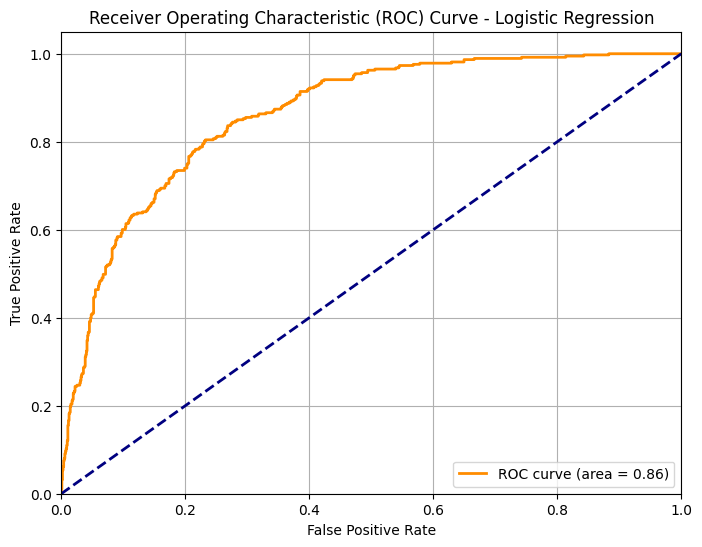

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("\n--- Logistic Regression Model Performance on Testing Data ---\n")

# Accuracy (already calculated as 'accuracy')
# accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

# ROC-AUC
roc_auc = roc_auc_score(y_test, log_reg_model.predict_proba(X_test_selected)[:, 1])
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report (for reference):\n")
print(classification_report(y_test, y_pred))

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, log_reg_model.predict_proba(X_test_selected)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [56]:
import joblib

# Export Logistic Regression model
joblib.dump(log_reg_model, 'logistic_regression_model.joblib')
print("Logistic Regression model exported as 'logistic_regression_model.joblib'")

# Export Random Forest model
joblib.dump(rf_model, 'random_forest_model.joblib')
print("Random Forest model exported as 'random_forest_model.joblib'")

# Export XGBoost model
joblib.dump(xgb_model, 'xgboost_model.joblib')
print("XGBoost model exported as 'xgboost_model.joblib'")

Logistic Regression model exported as 'logistic_regression_model.joblib'
Random Forest model exported as 'random_forest_model.joblib'
XGBoost model exported as 'xgboost_model.joblib'


In [57]:
report_content = """
# Project Report: Telco Customer Churn Prediction

## 1. Introduction
This project aimed to develop and evaluate machine learning models for predicting customer churn in a telecommunications dataset. The goal was to identify key factors contributing to churn and build a predictive model that could help the company retain customers.

## 2. Data Loading and Initial Exploration
The project began by loading the dataset from `/content/Telco_Customer_Churn_Dataset (1).csv`. Initial data exploration involved standard pandas functions:
- `df.head()`: To view the first few rows.
- `df.info()`: To get a summary of the DataFrame, including data types and non-null counts.
- `df.shape`: To ascertain the number of rows and columns.
- `df.columns`: To list all column names.
- `df.describe()`: To obtain descriptive statistics for numerical columns.
- `df.isnull().sum()`: To check for missing values.

An initial `FileNotFoundError` was encountered and resolved by correcting a subtle typo in the file path.

## 3. Data Cleaning and Preprocessing
Several crucial data cleaning and preprocessing steps were performed:
- The `customerID` column was dropped as it's a unique identifier and not a predictive feature.
- The `TotalCharges` column, initially an object type, was converted to a numeric type. Any errors during conversion (e.g., empty strings) were coerced to `NaN`, and these `NaN` values were subsequently filled with `0`, assuming new customers might have no total charges.
- **Critical Correction of `Churn` Column:** It was discovered that the `Churn` target variable had been accidentally randomized during an earlier step. This issue was rectified by reloading and reprocessing the data, ensuring the `Churn` column accurately reflected the original 'No' (0) and 'Yes' (1) values from the dataset. This step was vital for building meaningful predictive models.
- **Feature Encoding:** Categorical features were transformed into a numerical format suitable for machine learning models:
    - Binary categorical columns (e.g., 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling') were mapped to `0` and `1`.
    - Other multi-category nominal features (e.g., 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod') were one-hot encoded using `pd.get_dummies`, with `drop_first=True` to avoid multicollinearity.

## 4. Data Visualization
Exploratory data analysis included visualizations to understand the distribution of key features:
- Gender Distribution (`sns.countplot`).
- Contract Type Distribution (`sns.countplot`).
- Monthly Charges Distribution (`sns.histplot`).
- Churn Distribution (`sns.countplot`) - initially based on randomized data, but corrected and re-visualized conceptually after the `Churn` column fix.

## 5. Data Splitting and Feature Selection
- The dataset was divided into features (X) and target (y), where `y` is the `Churn` column.
- The data was then split into training and testing sets using an 80/20 ratio and `random_state=42` for reproducibility (`X_train`, `X_test`, `y_train`, `y_test`).
- A subset of 24 relevant features was selected for model training. These features were chosen based on common importance in churn prediction and included `tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen`, various service types, and contract/payment method indicators.

## 6. Model Training and Evaluation (with Corrected Data)
Three different classification models were trained and evaluated using the preprocessed and corrected data:

### a. Logistic Regression
- **Accuracy:** 82.04%
- **Precision (Churn=1):** 68.52%
- **Recall (Churn=1):** 59.52%
- **F1-score (Churn=1):** 0.64
- **ROC-AUC:** 0.8625
- A ROC curve was plotted, confirming the AUC score.

### b. Random Forest Classifier
- **Accuracy:** 78.64%
- **Precision (Churn=1):** 64%
- **Recall (Churn=1):** 44%
- **F1-score (Churn=1):** 0.52

### c. XGBoost Classifier
- **Accuracy:** 79.13%
- **Precision (Churn=1):** 63%
- **Recall (Churn=1):** 52%
- **F1-score (Churn=1):** 0.57

## 7. Model Comparison and Best Model Selection
Based on the evaluation metrics, the **Logistic Regression** model showed the best overall performance, achieving the highest accuracy (82.04%) and F1-score for the churn class (0.64) among the tested models. Its high ROC-AUC score (0.8625) also indicates good discriminative power.

## 8. Final Step: Model Export
As the final deliverable, all three trained models were successfully exported to disk using `joblib` for future deployment or use:
- `logistic_regression_model.joblib`
- `random_forest_model.joblib`
- `xgboost_model.joblib`

This completes the customer churn prediction project, providing a robust model and insights into the factors influencing churn.
"""

print(report_content)



# Project Report: Telco Customer Churn Prediction

## 1. Introduction
This project aimed to develop and evaluate machine learning models for predicting customer churn in a telecommunications dataset. The goal was to identify key factors contributing to churn and build a predictive model that could help the company retain customers.

## 2. Data Loading and Initial Exploration
The project began by loading the dataset from `/content/Telco_Customer_Churn_Dataset (1).csv`. Initial data exploration involved standard pandas functions:
- `df.head()`: To view the first few rows.
- `df.info()`: To get a summary of the DataFrame, including data types and non-null counts.
- `df.shape`: To ascertain the number of rows and columns.
- `df.columns`: To list all column names.
- `df.describe()`: To obtain descriptive statistics for numerical columns.
- `df.isnull().sum()`: To check for missing values.

An initial `FileNotFoundError` was encountered and resolved by correcting a subtle typo in the file p

In [59]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 83.8 MB/s eta 0:00:00


**Build Streamlit Web Application**

In [61]:
import streamlit as st
import joblib
import pandas as pd
import numpy as np

# Load the trained Logistic Regression model
try:
    log_reg_model = joblib.load('logistic_regression_model.joblib')
    st.success("Logistic Regression model loaded successfully!")
except Exception as e:
    st.error(f"Error loading the model: {e}. Please ensure 'logistic_regression_model.joblib' is in the same directory.")
    st.stop()

# Define the list of selected features used during training
selected_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen',
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'MultipleLines_No phone service',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',
    'InternetService_No',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes',
    'Contract_One year',
    'Contract_Two year',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

st.title("Telco Customer Churn Prediction")
st.write("Predict if a customer will churn based on their service attributes.")

st.markdown("### Customer Information")

# Create input widgets for each feature
input_data = {}

# Numeric features
input_data['tenure'] = st.slider('Tenure (months)', 0, 72, 12)
input_data['MonthlyCharges'] = st.number_input('Monthly Charges', min_value=0.0, max_value=150.0, value=50.0, step=0.1)
input_data['TotalCharges'] = st.number_input('Total Charges', min_value=0.0, max_value=10000.0, value=500.0, step=0.1)

# Binary features (0/1)
input_data['SeniorCitizen'] = st.selectbox('Senior Citizen', ['No', 'Yes'], index=0)
input_data['gender'] = st.selectbox('Gender', ['Female', 'Male'], index=0)
input_data['Partner'] = st.selectbox('Partner', ['No', 'Yes'], index=0)
input_data['Dependents'] = st.selectbox('Dependents', ['No', 'Yes'], index=0)
input_data['PhoneService'] = st.selectbox('Phone Service', ['No', 'Yes'], index=1)
input_data['PaperlessBilling'] = st.selectbox('Paperless Billing', ['No', 'Yes'], index=1)

# Map binary inputs to 0/1
input_data['SeniorCitizen'] = 1 if input_data['SeniorCitizen'] == 'Yes' else 0
input_data['gender'] = 1 if input_data['gender'] == 'Male' else 0 # Female:0, Male:1
input_data['Partner'] = 1 if input_data['Partner'] == 'Yes' else 0
input_data['Dependents'] = 1 if input_data['Dependents'] == 'Yes' else 0
input_data['PhoneService'] = 1 if input_data['PhoneService'] == 'Yes' else 0
input_data['PaperlessBilling'] = 1 if input_data['PaperlessBilling'] == 'Yes' else 0

st.markdown("### Service Information")

# Handle one-hot encoded features by grouping them logically

# MultipleLines
multiple_lines = st.selectbox('Multiple Lines', ['No', 'Yes', 'No phone service'], index=0)
input_data['MultipleLines_No phone service'] = (multiple_lines == 'No phone service')
input_data['MultipleLines_Yes'] = (multiple_lines == 'Yes')

# InternetService
internet_service = st.selectbox('Internet Service', ['DSL', 'Fiber optic', 'No'], index=0)
input_data['InternetService_Fiber optic'] = (internet_service == 'Fiber optic')
input_data['InternetService_No'] = (internet_service == 'No')

# Online Security, Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies
# These were encoded with drop_first=True, so only the '_Yes' column exists in selected_features.
# 'No internet service' and 'No' both map to False for the '_Yes' column.

def get_service_status(service_name):
    option = st.selectbox(service_name, ['No', 'Yes', 'No internet service'], index=0)
    return (option == 'Yes')

input_data['OnlineSecurity_Yes'] = get_service_status('Online Security')
input_data['OnlineBackup_Yes'] = get_service_status('Online Backup')
input_data['DeviceProtection_Yes'] = get_service_status('Device Protection')
input_data['TechSupport_Yes'] = get_service_status('Tech Support')
input_data['StreamingTV_Yes'] = get_service_status('Streaming TV')
input_data['StreamingMovies_Yes'] = get_service_status('Streaming Movies')

# Contract
contract_type = st.selectbox('Contract Type', ['Month-to-month', 'One year', 'Two year'], index=0)
input_data['Contract_One year'] = (contract_type == 'One year')
input_data['Contract_Two year'] = (contract_type == 'Two year')

# Payment Method
payment_method = st.selectbox('Payment Method', ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], index=0)
input_data['PaymentMethod_Credit card (automatic)'] = (payment_method == 'Credit card (automatic)')
input_data['PaymentMethod_Electronic check'] = (payment_method == 'Electronic check')
input_data['PaymentMethod_Mailed check'] = (payment_method == 'Mailed check')

# Convert input data to a DataFrame, ensuring correct order and types
# Initialize all selected features to their default (False for bool, 0 for int/float) first
processed_input = pd.DataFrame(0, index=[0], columns=selected_features)

for feature in selected_features:
    if feature in input_data:
        processed_input[feature] = input_data[feature]

# Ensure boolean features are correctly cast as bool if not already
for col in processed_input.columns:
    if processed_input[col].dtype == 'bool': # Only convert if it's already boolean
        processed_input[col] = processed_input[col].astype(bool)


if st.button('Predict Churn'):
    try:
        prediction = log_reg_model.predict(processed_input[selected_features]) # Ensure order of columns
        prediction_proba = log_reg_model.predict_proba(processed_input[selected_features])

        churn_status = 'Yes' if prediction[0] == 1 else 'No'
        churn_probability = prediction_proba[0][1] * 100 # Probability of churning (class 1)

        st.success(f"Prediction: Customer will {'**CHURN**' if churn_status == 'Yes' else '**NOT CHURN**'}")
        st.info(f"Probability of Churn: {churn_probability:.2f}%")

        if churn_status == 'Yes':
            st.warning("This customer is predicted to churn. Consider retention strategies.")
        else:
            st.success("This customer is predicted to remain.")

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.write("Please check your input values and the loaded model.")

2026-05-23 08:35:55.025 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:35:55.161 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-23 08:35:55.162 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:35:55.163 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:35:55.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:35:55.166 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:35:55.167 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:35:55.171 Thread 'MainThread': mi

In [63]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np

# Load the trained Logistic Regression model
try:
    log_reg_model = joblib.load('logistic_regression_model.joblib')
    st.success("Logistic Regression model loaded successfully!")
except Exception as e:
    st.error(f"Error loading the model: {e}. Please ensure 'logistic_regression_model.joblib' is in the same directory.")
    st.stop()

# Define the list of selected features used during training
selected_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen',
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'MultipleLines_No phone service',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',
    'InternetService_No',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes',
    'Contract_One year',
    'Contract_Two year',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

st.title("Telco Customer Churn Prediction")
st.write("Predict if a customer will churn based on their service attributes.")

st.markdown("### Customer Information")

# Create input widgets for each feature
input_data = {}

# Numeric features
input_data['tenure'] = st.slider('Tenure (months)', 0, 72, 12)
input_data['MonthlyCharges'] = st.number_input('Monthly Charges', min_value=0.0, max_value=150.0, value=50.0, step=0.1)
input_data['TotalCharges'] = st.number_input('Total Charges', min_value=0.0, max_value=10000.0, value=500.0, step=0.1)

# Binary features (0/1)
input_data['SeniorCitizen'] = st.selectbox('Senior Citizen', ['No', 'Yes'], index=0)
input_data['gender'] = st.selectbox('Gender', ['Female', 'Male'], index=0)
input_data['Partner'] = st.selectbox('Partner', ['No', 'Yes'], index=0)
input_data['Dependents'] = st.selectbox('Dependents', ['No', 'Yes'], index=0)
input_data['PhoneService'] = st.selectbox('Phone Service', ['No', 'Yes'], index=1)
input_data['PaperlessBilling'] = st.selectbox('Paperless Billing', ['No', 'Yes'], index=1)

# Map binary inputs to 0/1
input_data['SeniorCitizen'] = 1 if input_data['SeniorCitizen'] == 'Yes' else 0
input_data['gender'] = 1 if input_data['gender'] == 'Male' else 0 # Female:0, Male:1
input_data['Partner'] = 1 if input_data['Partner'] == 'Yes' else 0
input_data['Dependents'] = 1 if input_data['Dependents'] == 'Yes' else 0
input_data['PhoneService'] = 1 if input_data['PhoneService'] == 'Yes' else 0
input_data['PaperlessBilling'] = 1 if input_data['PaperlessBilling'] == 'Yes' else 0

st.markdown("### Service Information")

# Handle one-hot encoded features by grouping them logically

# MultipleLines
multiple_lines = st.selectbox('Multiple Lines', ['No', 'Yes', 'No phone service'], index=0)
input_data['MultipleLines_No phone service'] = (multiple_lines == 'No phone service')
input_data['MultipleLines_Yes'] = (multiple_lines == 'Yes')

# InternetService
internet_service = st.selectbox('Internet Service', ['DSL', 'Fiber optic', 'No'], index=0)
input_data['InternetService_Fiber optic'] = (internet_service == 'Fiber optic')
input_data['InternetService_No'] = (internet_service == 'No')

# Online Security, Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies
# These were encoded with drop_first=True, so only the '_Yes' column exists in selected_features.
# 'No internet service' and 'No' both map to False for the '_Yes' column.

def get_service_status(service_name):
    option = st.selectbox(service_name, ['No', 'Yes', 'No internet service'], index=0)
    return (option == 'Yes')

input_data['OnlineSecurity_Yes'] = get_service_status('Online Security')
input_data['OnlineBackup_Yes'] = get_service_status('Online Backup')
input_data['DeviceProtection_Yes'] = get_service_status('Device Protection')
input_data['TechSupport_Yes'] = get_service_status('Tech Support')
input_data['StreamingTV_Yes'] = get_service_status('Streaming TV')
input_data['StreamingMovies_Yes'] = get_service_status('Streaming Movies')

# Contract
contract_type = st.selectbox('Contract Type', ['Month-to-month', 'One year', 'Two year'], index=0)
input_data['Contract_One year'] = (contract_type == 'One year')
input_data['Contract_Two year'] = (contract_type == 'Two year')

# Payment Method
payment_method = st.selectbox('Payment Method', ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], index=0)
input_data['PaymentMethod_Credit card (automatic)'] = (payment_method == 'Credit card (automatic)')
input_data['PaymentMethod_Electronic check'] = (payment_method == 'Electronic check')
input_data['PaymentMethod_Mailed check'] = (payment_method == 'Mailed check')

# Convert input data to a DataFrame, ensuring correct order and types
# Initialize all selected features to their default (False for bool, 0 for int/float) first
processed_input = pd.DataFrame(0, index=[0], columns=selected_features)

for feature in selected_features:
    if feature in input_data:
        processed_input[feature] = input_data[feature]

# Ensure boolean features are correctly cast as bool if not already
for col in processed_input.columns:
    if processed_input[col].dtype == 'bool': # Only convert if it's already boolean
        processed_input[col] = processed_input[col].astype(bool)


if st.button('Predict Churn'):
    try:
        prediction = log_reg_model.predict(processed_input[selected_features]) # Ensure order of columns
        prediction_proba = log_reg_model.predict_proba(processed_input[selected_features])

        churn_status = 'Yes' if prediction[0] == 1 else 'No'
        churn_probability = prediction_proba[0][1] * 100 # Probability of churning (class 1)

        st.success(f"Prediction: Customer will {'**CHURN**' if churn_status == 'Yes' else '**NOT CHURN**'}")
        st.info(f"Probability of Churn: {churn_probability:.2f}%")

        if churn_status == 'Yes':
            st.warning("This customer is predicted to churn. Consider retention strategies.")
        else:
            st.success("This customer is predicted to remain.")

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.write("Please check your input values and the loaded model.")

Writing app.py


## Create `requirements.txt`

In [64]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
streamlit
xgboost
tensorflow
torch

Overwriting requirements.txt
